# Visualize Cluster


In [2]:
import os

os.chdir("/media/trdp/STORAGE/3.Trabalho/PhD-Research/ThesisExperiments/3.ToValidate/TextualHGNN")

In [3]:
import torch
import json
import logging
from src.utils.general_utils import load_config
from src.data.preprocessing import preprocessing_legal_pt_voto_relatorio

BEST_MODEL_PATH = "models/grid_search/STF_HC_Voto_Relatorio/best_model_20250829_234323_lk0.0_en0.0_rc0.0_ct0.0_bl1.0_rp0.0_l20.0.pth"
DEFAULT_MODEL_PATH = "models/grid_search/STF_HC_Voto_Relatorio/best_model_20250829_234323_lk0.0_en0.0_rc0.0_ct0.0_bl0.0_rp0.0_l20.0.pth"

weights_best_model = torch.load(BEST_MODEL_PATH)
weights_default_model = torch.load(DEFAULT_MODEL_PATH)

LANG = "portuguese_voto"
DATASET = "STF_HC_Voto_Relatorio"
CONFIG = load_config(LANG, "src/utils/config.json")
ROOT = f"data/datasets/{DATASET}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = BEST_MODEL_PATH
BEST_MODEL_PATH = "models/grid_search/STF_HC_Voto_Relatorio/best_model_20250829_234323_lk0.0_en0.0_rc0.0_ct0.0_bl1.0_rp0.0_l20.0.pth"


logging.info(f"============  STARTING CG EXPERIMENT {DATASET}  ============")
logging.info(f"CONFIG: \n{json.dumps(CONFIG, indent=3)}\n")
logging.info(f"MODEL CHECKPOINT: {MODEL_PATH}")

weights = torch.load(MODEL_PATH)
EMBEDDING_PATH = "data/external/embeddings/glove_legal_100.bin"
EMBEDDINGS_DATABASE_PATH = f"data/oracle/embeddings_{DATASET}.db"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = f"data/datasets/{DATASET}"
DOCUMENTS_TO_EXPLAIN = 2


/tmp/ipykernel_18523/4251266150.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_best_model = torch.load(BEST_MODEL_PATH)
/tmp/ipykernel_18523/4251266150.py:11: 

In [4]:

weights_best_model = torch.load(BEST_MODEL_PATH)
weights_default_model = torch.load(DEFAULT_MODEL_PATH)

/tmp/ipykernel_18523/1184731218.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_best_model = torch.load(BEST_MODEL_PATH)
/tmp/ipykernel_18523/1184731218.py:2: Fu

In [5]:
from src.utils.general_utils import load_config

LANG = "portuguese_voto"
DATASET = "STF_HC_Voto_Relatorio"
CONFIG = load_config(LANG, "src/utils/config.json")
ROOT = f"data/datasets/{DATASET}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
from src.models.graph_classification.gnn import DiffPool

best_diffpool_model = DiffPool(
    max_num_nodes=3000,
    in_channels=100,
    hidden_channels=100,
    out_channels=2,
    inner_channels=32,
    softmax_assign=True,
    decrease_proportion=0.1,
)
best_diffpool_model.load_state_dict(weights_best_model)
best_diffpool_model = best_diffpool_model.to(device=DEVICE)

In [7]:
from pathlib import Path
from src.data.text_graph_dataset_ondisk import TextGraphDatasetOnDisk
import torch_geometric.transforms as T

tgd_test = TextGraphDatasetOnDisk(
    root=ROOT,
    split="test",
    batch_size=1,
    node_feature_size=100,
    transform=T.ToDense(num_nodes=1000),
    max_num_nodes=1000,
    lang=LANG
)

nx_graphs = Path(ROOT) / "test" / "interim"
nx_graphs = str(nx_graphs) + "/*.pt"




[nltk_data] Downloading package punkt to /home/trdp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [8]:
data_sample = tgd_test[0].to(DEVICE)

In [9]:
data_sample

Data(x=[1000, 100], y=[8], doc_id=[8], adj=[1000, 1000], mask=[1000])

In [10]:
import glob

stored_graph_paths = glob.glob(nx_graphs)
stored_graph_paths = list(stored_graph_paths)
print(f"NX Graphs at '{nx_graphs}' with: {len(stored_graph_paths)} NX graphs.")

NX Graphs at 'data/datasets/STF_HC_Voto_Relatorio/test/interim/*.pt' with: 203 NX graphs.


In [61]:
data_sample_id = int.from_bytes(data_sample.doc_id, byteorder='little')

with torch.no_grad():
    prediction = best_diffpool_model(data_sample.x, data_sample.adj, debug=True)

y_pred, obj1, obj2, g_layer1, g_layer2, s = prediction
y_pred = torch.softmax(y_pred, dim=1)
s01, s12 = s
x_l1, adj_l1 = g_layer1
x_l2, adj_l2 = g_layer2

print(f"Data sample: {data_sample_id} with prediction {y_pred.cpu()}")

Data sample: 977 with prediction tensor([[0.3621, 0.6379]])


In [62]:
s01 = s01.squeeze(0)
s12 = s12.squeeze(0)
x_l0 = data_sample.x.squeeze(0)
adj_l0 = data_sample.adj.squeeze(0)
x_l1 = x_l1.squeeze(0)
adj_l1 = adj_l1.squeeze(0)
x_l2 = x_l2.squeeze(0)
adj_l2 = adj_l2.squeeze(0)
y_pred = torch.argmax(y_pred, dim=1).item()
y_test = int.from_bytes(data_sample.y, byteorder='little')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
raw_file_path = Path(f"{ROOT}/test/raw/")



labels = {0: "Preso", 1: 'Solto'}

label = labels[y_test]

print(f"Prediction: {labels[y_pred]}, True: {labels[y_test]}")

Prediction: Solto, True: Preso


In [63]:
raw_file_content = open(raw_file_path / f"{label}/{data_sample_id}.txt", "r").read().strip()

print(preprocessing_legal_pt_voto_relatorio(raw_file_content))

RELATÓRIO:
HABEAS CORPUS 122.029 PARANÁ COATOR(A/S)(ES) : SUPERIOR TRIBUNAL DE JUSTIÇA

RE LAT Ó RI O:
O SENHOR MINISTRO RICARDO LEWANDOWSKI (RELATOR): Trata-se de habeas corpus, com pedido de medida liminar, impetrado pela Defensoria Pública da União, em favor de MOISÉS TABORDA DOS SANTOS, contra acórdão da Sexta Turma do Superior Tribunal de Justiça, que negou provimento ao agravo regimental no REsp 1.342.520/PR, Rel. Min. Sebastião Reis Júnior. Consta dos autos que o paciente foi denunciado pela suposta prática do crime previsto no ARTIGO_334, paragrafo 1º, b, do Código Penal (contrabando ou descaminho), por manter em depósito, em sua residência: 15.000 (quinze mil) maços de cigarro oriundos do Paraguai, desprovidos de qualquer selo de controle da Receita Federal e internalizados em território brasileiro sem o pagamento dos impostos devidos; aproximadamente 4 (quatro) gramas de cocaína; e 10 (dez) comprimidos de medicamentos. Contudo, após o oferecimento da resposta à acusação, o Ju

In [64]:
mask = x_l0.abs().sum(dim=1) > 1e-9   # Boolean mask, True if row is not all zeros
x_l0_filtered = x_l0[mask]                        # Keep only non-zero rows
s01_filtered = s01[mask]


In [65]:
x_l0_filtered.shape


torch.Size([465, 100])

In [66]:
s01_filtered.shape

torch.Size([465, 300])

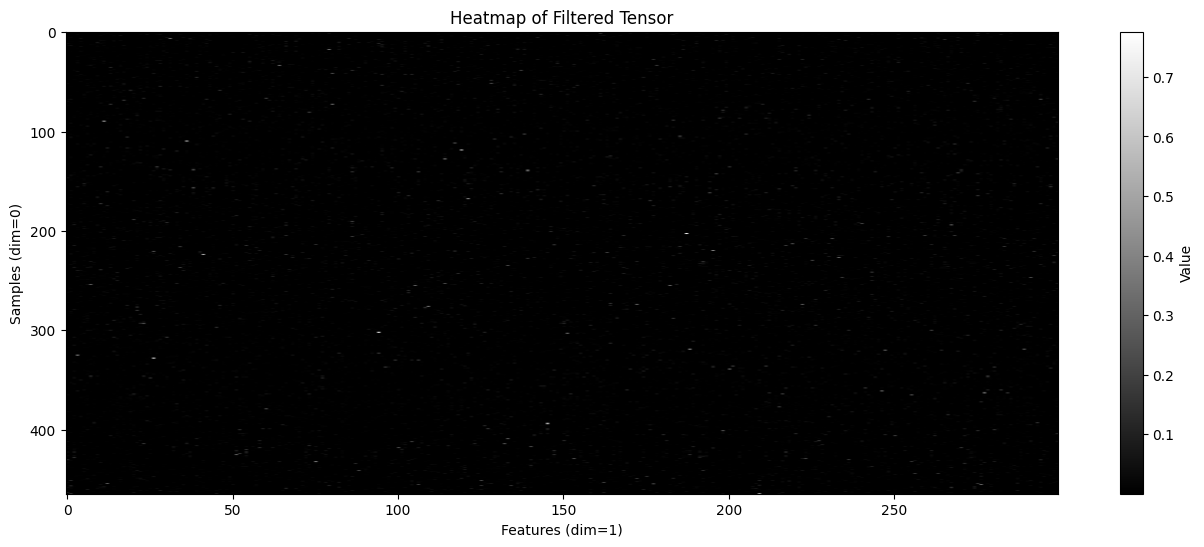

In [67]:
from matplotlib import pyplot as plt

# 2. Plot heatmap
plt.figure(figsize=(16, 6))
plt.imshow(s01_filtered.cpu().numpy(), aspect='auto', cmap='gray')
plt.colorbar(label="Value")
plt.xlabel("Features (dim=1)")
plt.ylabel("Samples (dim=0)")
plt.title("Heatmap of Filtered Tensor")
plt.show()

In [68]:
assignments = s01_filtered.argmax(dim=1)   # shape: [num_rows], values ∈ [0..299]

In [69]:
from collections import Counter
ass = assignments.cpu().tolist()
counts = Counter(ass)   # dictionary {column_index: count}



In [103]:
X = s01_filtered.cpu().numpy()
X = s12.cpu().numpy()


global: 0.9847337942302218


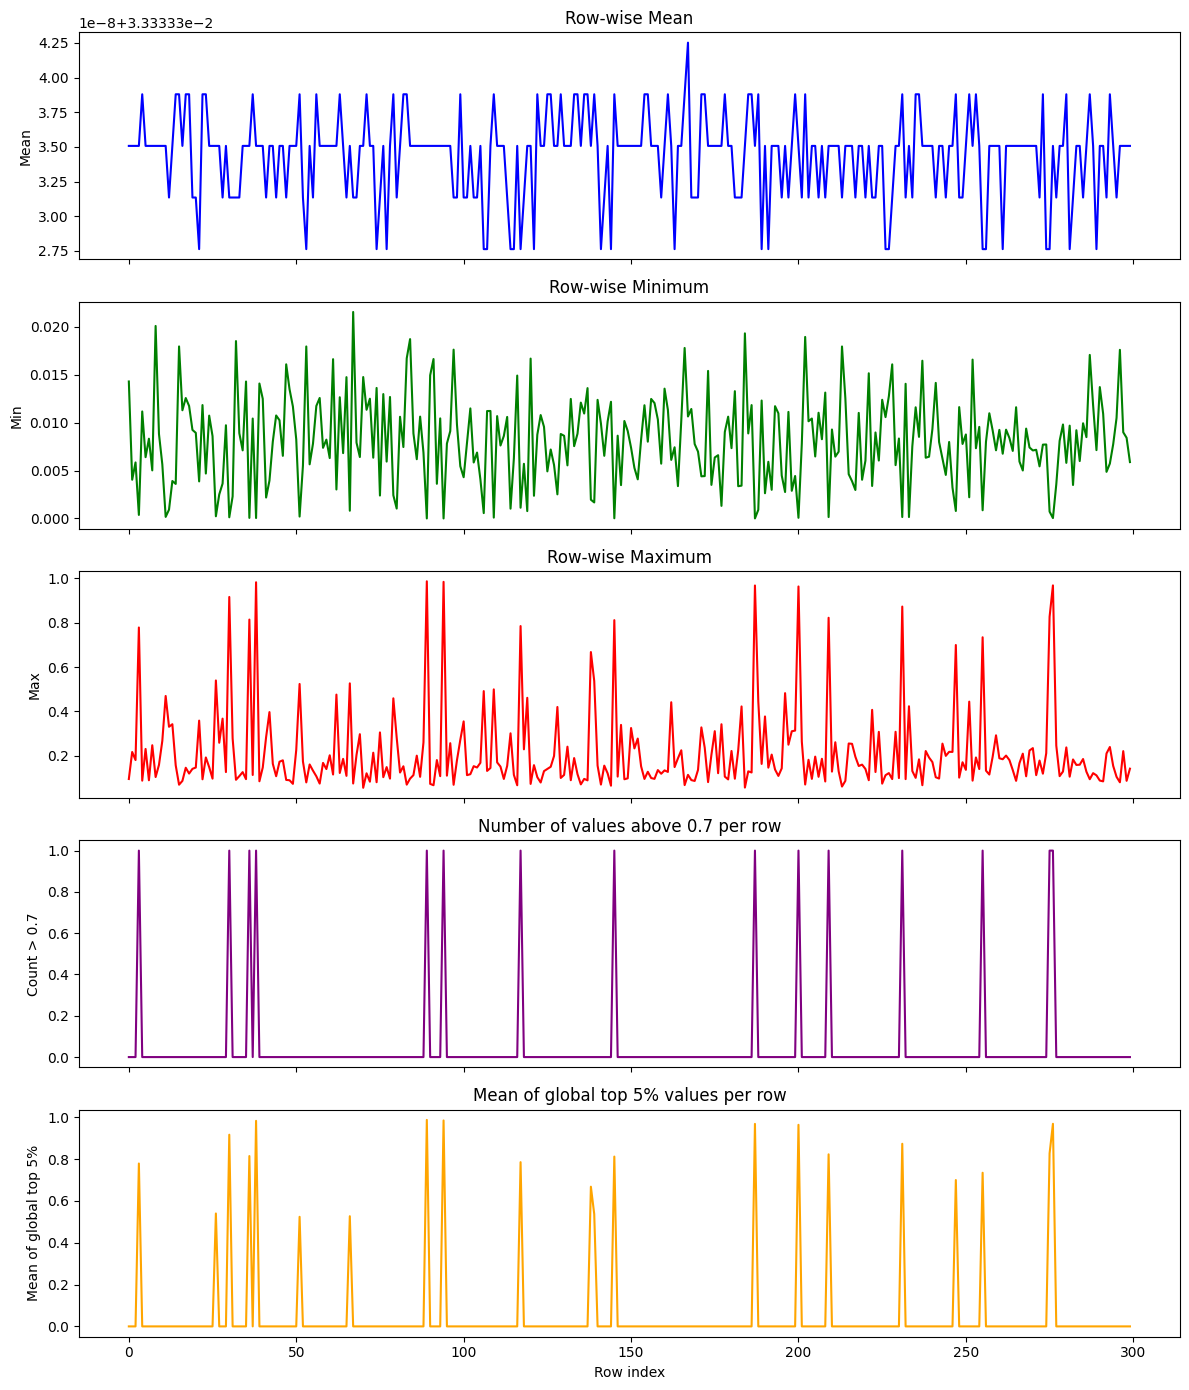

In [104]:
import numpy as np

# Example data
data =X


# Compute statistics for each row
row_means = np.mean(data, axis=1)
row_mins = np.min(data, axis=1)
row_maxs = np.max(data, axis=1)

# Threshold
threshold = 0.7
above_threshold_count = np.sum(data > threshold, axis=1)

# Global top 5%
global_top_threshold = np.percentile(data, 99.99)
print(f"global: {global_top_threshold}")
top_5_mask = data >= 0.5
top_5_values_per_row = [row[row_mask] for row, row_mask in zip(data, top_5_mask)]
# For plotting, use count or mean
top_5_mean_per_row = np.array([vals.mean() if len(vals) > 0 else 0 for vals in top_5_values_per_row])

# Create a figure with 5 subplots
fig, axs = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

# Plot row-wise means
axs[0].plot(row_means, color='blue')
axs[0].set_ylabel('Mean')
axs[0].set_title('Row-wise Mean')

# Plot row-wise minimums
axs[1].plot(row_mins, color='green')
axs[1].set_ylabel('Min')
axs[1].set_title('Row-wise Minimum')

# Plot row-wise maximums
axs[2].plot(row_maxs, color='red')
axs[2].set_ylabel('Max')
axs[2].set_title('Row-wise Maximum')

# Plot threshold counts
axs[3].plot(above_threshold_count, color='purple')
axs[3].set_ylabel(f'Count > {threshold}')
axs[3].set_title(f'Number of values above {threshold} per row')

# Plot global top 5% mean values per row
axs[4].plot(top_5_mean_per_row, color='orange')
axs[4].set_ylabel('Mean of global top 5%')
axs[4].set_xlabel('Row index')
axs[4].set_title('Mean of global top 5% values per row')

plt.tight_layout()
plt.show()


